# Compare FOV grids: 60X vs 40X objective

Based on `before_imaging/02_create_positions_from_boundaries.ipynb` (the
production notebook that turns a tissue boundary into the FOV scanning
grid), applied to the same real, saved lineage-tracing dataset used by
`compare_fov_coverage_constraint.ipynb`: the LT060_sample_04 mosaic-derived
boundary + 7 holes (`data/positions/examples/lineage_tracing_mosaic/`) and
its assembled mosaic canvas (`data/mosaic_canvas_examples/lineage_tracing/canvas.npz`).

**Why this isn't just `get_fov_geometry(microscope)`**: MERci's per-microscope
camera-geometry table (`acquisition/configs.py`) hard-codes one sample-plane
pixel size per scope (e.g. ST2 -> 0.0878 um/px), calibrated at **60X** (see
`README.md`'s `MF2_60XSil1.3_zcorrection.ipynb` -- "z-correction for the MF2
60x silicone objective"). There is no 40X entry to look up. Swapping the
objective doesn't change the camera's physical pixel count, only the
magnification -- so a 40X pixel size is derived here by scaling the 60X
value by the magnification ratio (`60/40`), sensor size held fixed:

```
pixel_size_um(40X) = pixel_size_um(60X) * (60 / 40)
```

A lower magnification projects each physical camera pixel onto a *larger*
patch of the sample, so 40X gives a larger `fov_size_um` (same pixel count,
coarser sampling) -- fewer, bigger FOVs cover the same tissue.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# notebooks/tests/ is two levels under the repo root (MERci/), same
# convention as notebooks/misc/ and notebooks/during_imaging/.
MERCI_DIR  = Path(os.getcwd()).parent.parent   # MERci/
SAMPLE_DIR = MERCI_DIR.parent                  # this repo's own sandbox experiment
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs   import get_camera_pixel_size_um, get_camera_frame_size
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons,
    build_boundary_path_optimized, get_path_stats,
)
from MERci.acquisition.mosaic    import load_mosaic_canvas

## Load the saved dataset (real LT060_sample_04 mosaic-derived boundary)

Same boundary + holes + assembled canvas as `compare_fov_coverage_constraint.ipynb`
-- a real, complex single-tissue section, not a synthetic example.

In [2]:
BOUNDARY_DIR = MERCI_DIR / "data" / "positions" / "examples" / "lineage_tracing_mosaic"
CANVAS_PATH  = MERCI_DIR / "data" / "mosaic_canvas_examples" / "lineage_tracing" / "canvas.npz"

boundary_polygon = load_boundary_polygon(BOUNDARY_DIR / "boundary_positions.txt")
hole_polygons    = load_hole_polygons(BOUNDARY_DIR)
canvas           = load_mosaic_canvas(CANVAS_PATH)

print(f"Boundary   : {BOUNDARY_DIR / 'boundary_positions.txt'}")
print(f"Tissue area: {boundary_polygon.area / 1e6:.2f} mm^2")
print(f"Holes      : {len(hole_polygons)}")
print(f"Canvas     : {CANVAS_PATH} ({canvas.image.shape[1]}x{canvas.image.shape[0]} px, "
      f"{canvas.pixel_size_um:.3f} um/px)")

Boundary   : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/data/positions/examples/lineage_tracing_mosaic/boundary_positions.txt
Tissue area: 32.32 mm^2
Holes      : 7
Canvas     : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/data/mosaic_canvas_examples/lineage_tracing/canvas.npz (2881x2881 px, 5.000 um/px)


## Objective geometry: 60X (production baseline) vs 40X (derived)

`MICROSCOPE = "ST2"` sets the camera (sensor pixel count, fixed by
hardware) and the 60X-calibrated sample-plane pixel size. The 40X entry
scales that pixel size by the magnification ratio only -- same sensor,
same `non_overlap_fraction`/`step_size` convention as
`before_imaging/02_create_positions_from_boundaries.ipynb`.

In [3]:
MICROSCOPE = "ST2"   # MFX/ST2: 0.0878 um/px @ 60X, 2304 px | MF2-MF5: 0.108 um/px @ 60X, 2048 px
image_size_px, _ = get_camera_frame_size(MICROSCOPE)   # square sensor -- fixed by hardware
pixel_size_60x_um = get_camera_pixel_size_um(MICROSCOPE)
pixel_size_40x_um = pixel_size_60x_um * (60.0 / 40.0)  # lower mag -> coarser sample-plane pixel

non_overlap_fraction = 0.9   # same convention as before_imaging/02
SCAN_DIRECTION        = "vertical"
GRID_OFFSET_SAMPLES   = 9    # production default (optimize_grid_offset)

OBJECTIVES = {
    "60X": pixel_size_60x_um,
    "40X": pixel_size_40x_um,
}

geometry = {}
for name, px_um in OBJECTIVES.items():
    fov_size_um  = px_um * image_size_px
    step_size_um = fov_size_um * non_overlap_fraction
    geometry[name] = {"pixel_size_um": px_um, "fov_size_um": fov_size_um, "step_size_um": step_size_um}
    print(f"{name}: {px_um:.4f} um/px, {image_size_px}x{image_size_px} px "
          f"-> fov_size {fov_size_um:.1f} um, step {step_size_um:.1f} um")

60X: 0.0878 um/px, 2304x2304 px -> fov_size 202.3 um, step 182.1 um
40X: 0.1317 um/px, 2304x2304 px -> fov_size 303.4 um, step 273.1 um


## Build the FOV grid for each objective

Same production pipeline as `before_imaging/02` (`build_boundary_path_optimized`,
`n_fovs`-first phase search) run once per objective, on the identical
boundary + holes -- the only thing that changes is `fov_size_um`/`step_size_um`.

In [4]:
paths = {}
for name, geo in geometry.items():
    coords = build_boundary_path_optimized(
        boundary_polygon, hole_polygons, geo["step_size_um"], geo["fov_size_um"],
        direction=SCAN_DIRECTION, n_samples=GRID_OFFSET_SAMPLES,
    )
    total_um, max_step_um = get_path_stats(coords)
    paths[name] = coords
    print(f"{name}: {len(coords):4d} FOVs   path length {total_um / 1000:6.2f} mm   "
          f"max step {max_step_um:.0f} um   FOV area {geo['fov_size_um']**2 / 1e6:.4f} mm^2")

ratio = len(paths['60X']) / len(paths['40X'])
print(f"\n60X needs {ratio:.2f}x as many FOVs as 40X to cover the same tissue.")

60X: 1152 FOVs   path length 226.62 mm   max step 1107 um   FOV area 0.0409 mm^2


40X:  550 FOVs   path length 158.56 mm   max step 1126 um   FOV area 0.0921 mm^2

60X needs 2.09x as many FOVs as 40X to cover the same tissue.


## Overview: boundary + FOV footprints, 60X vs 40X side by side

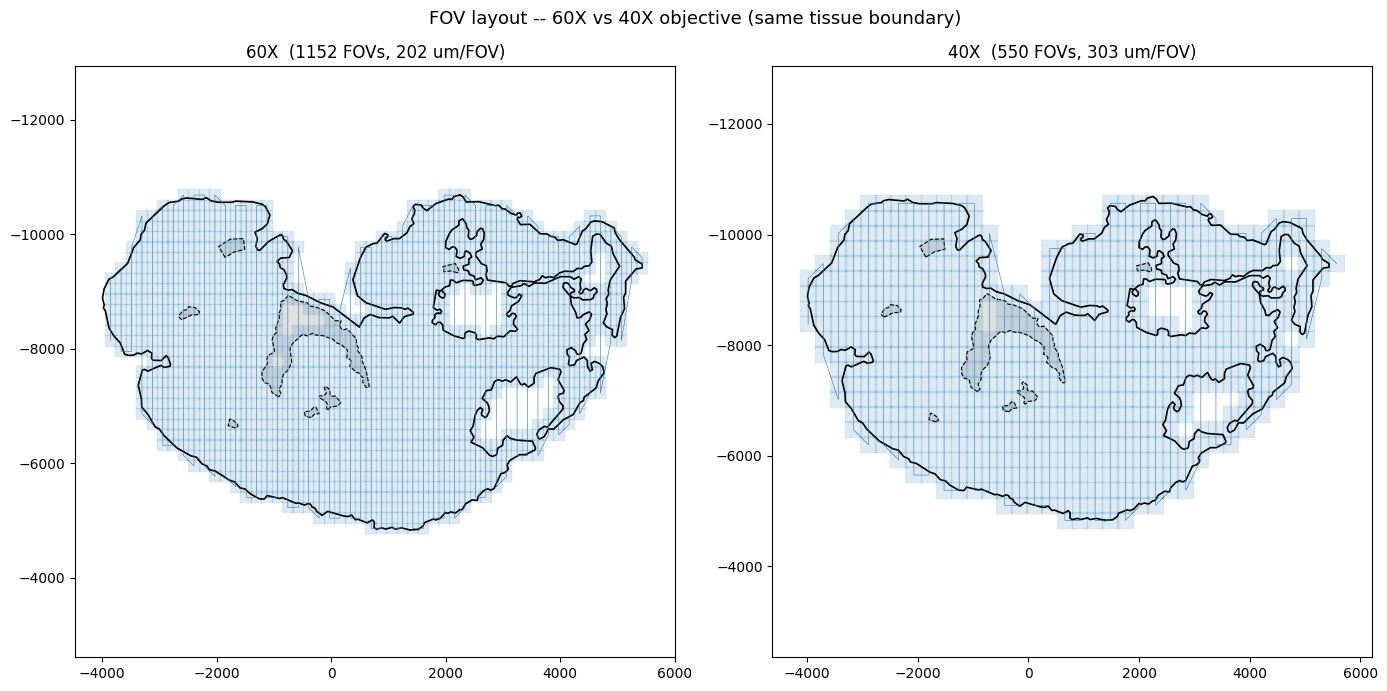

In [5]:
half = {name: geo["fov_size_um"] / 2 for name, geo in geometry.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, name in zip(axes, OBJECTIVES):
    coords = paths[name]
    ax.plot(*boundary_polygon.exterior.xy, "k-", lw=1.2)
    for hole in hole_polygons:
        ax.fill(*hole.exterior.xy, color="0.8", alpha=0.6)
        ax.plot(*hole.exterior.xy, "k--", lw=0.8)
    for x, y in coords:
        ax.add_patch(mpatches.Rectangle(
            (x - half[name], y - half[name]), geometry[name]["fov_size_um"], geometry[name]["fov_size_um"],
            lw=0.3, edgecolor="tab:blue", facecolor="tab:blue", alpha=0.15))
    ax.plot(coords[:, 0], coords[:, 1], "-", lw=0.4, color="tab:blue")
    ax.invert_yaxis(); ax.axis("equal")
    ax.set_title(f"{name}  ({len(coords)} FOVs, {geometry[name]['fov_size_um']:.0f} um/FOV)", fontsize=12)

fig.suptitle("FOV layout -- 60X vs 40X objective (same tissue boundary)", fontsize=13)
fig.tight_layout()
FIG_DIR = SAMPLE_DIR / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "compare_60x_40x_objective_fov_layout.png", dpi=150)
plt.show()

## FOV footprints over the real mosaic image, 60X vs 40X side by side

Same `(x, y)`-um -> canvas-pixel convention as
`before_imaging/02_create_positions_from_boundaries.ipynb`'s own
FOV-over-mosaic overlay: everything (image + FOV boxes) plotted in one
consistent pixel space, cropped to the tissue region with a small margin.

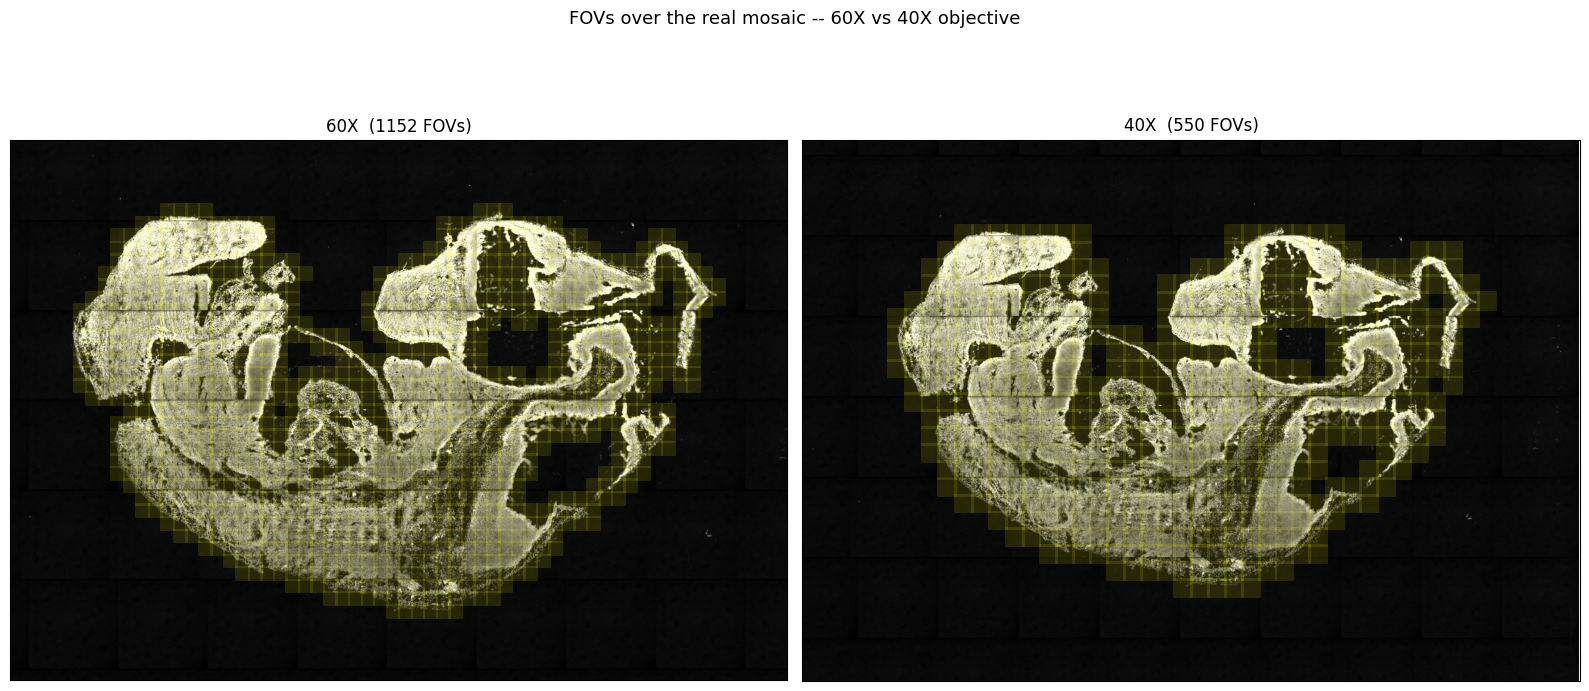

In [6]:
def _um_to_px(x, y):
    return ((np.asarray(x) - canvas.origin_um[0]) / canvas.pixel_size_um,
             (np.asarray(y) - canvas.origin_um[1]) / canvas.pixel_size_um)

covered_vals = canvas.image[canvas.covered]
vmin, vmax = np.percentile(covered_vals, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, name in zip(axes, OBJECTIVES):
    coords = paths[name]
    half_px = (geometry[name]["fov_size_um"] / 2) / canvas.pixel_size_um

    px, py = _um_to_px(coords[:, 0], coords[:, 1])
    margin_px = 5 * (geometry[name]["fov_size_um"] / canvas.pixel_size_um)
    x_min, x_max = px.min() - margin_px, px.max() + margin_px
    y_min, y_max = py.min() - margin_px, py.max() + margin_px

    ax.imshow(canvas.image, cmap="gray", vmin=vmin, vmax=vmax, origin="upper")
    for x, y in zip(px, py):
        ax.add_patch(mpatches.Rectangle(
            (x - half_px, y - half_px), 2 * half_px, 2 * half_px,
            lw=0.4, edgecolor="yellow", facecolor="yellow", alpha=0.12))
    # imshow's default origin puts row 0 at the top -- ylim must be (max, min)
    # to crop without flipping the image upside-down (see before_imaging/02's
    # own FOV-over-mosaic overlay, same convention).
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_max, y_min)
    ax.set_title(f"{name}  ({len(coords)} FOVs)", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("FOVs over the real mosaic -- 60X vs 40X objective", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "compare_60x_40x_objective_mosaic_overlay.png", dpi=150)
plt.show()

## Takeaways

- The 40X objective's `fov_size_um` is 1.5x the 60X value (`60/40` magnification
  ratio, same camera), so its FOV *area* is `1.5^2 = 2.25x` larger -- the FOV
  count / area-per-FOV printed above confirms this directly on the real
  boundary rather than assuming it from the ratio alone.
- Fewer, larger FOVs at 40X means less total scan travel and a shorter
  acquisition for the same tissue, at the cost of the coarser 40X sample-plane
  pixel size (see the `pixel_size_um` printed per objective above) -- a real
  resolution/throughput tradeoff, not just a scanning-grid one.
- This notebook only derives the 40X *geometry* by scaling the 60X
  calibration; it does not add a real per-objective calibration path to
  `acquisition/configs.py` -- if 40X imaging becomes a real acquisition
  option, `_CAMERA_PIXEL_SIZE_UM` (or a new objective-aware lookup) should
  be extended with an actually-measured value instead of this derived one.